<a href="https://colab.research.google.com/github/chiraswykj/ML2_Lab_ChiraswyKJ_4NI23CI028/blob/main/ML_Exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (569, 30)
Target Distribution:
1    62.74%
0    37.26%
Name: proportion, dtype: object

--- Performance Report ---
                       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Boosting (Gradient Boosting)    0.9561     0.9467  0.9861    0.9660   0.9907
         Boosting (AdaBoost)    0.9561     0.9467  0.9861    0.9660   0.9818
     Bagging (Random Forest)    0.9561     0.9589  0.9722    0.9655   0.9937
           Bagging (Generic)    0.9386     0.9452  0.9583    0.9517   0.9927
        Single Decision Tree    0.9123     0.9559  0.9028    0.9286   0.9157


/tmp/ipykernel_1340/714446622.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="ROC-AUC", ax=axes[1], palette="crest")


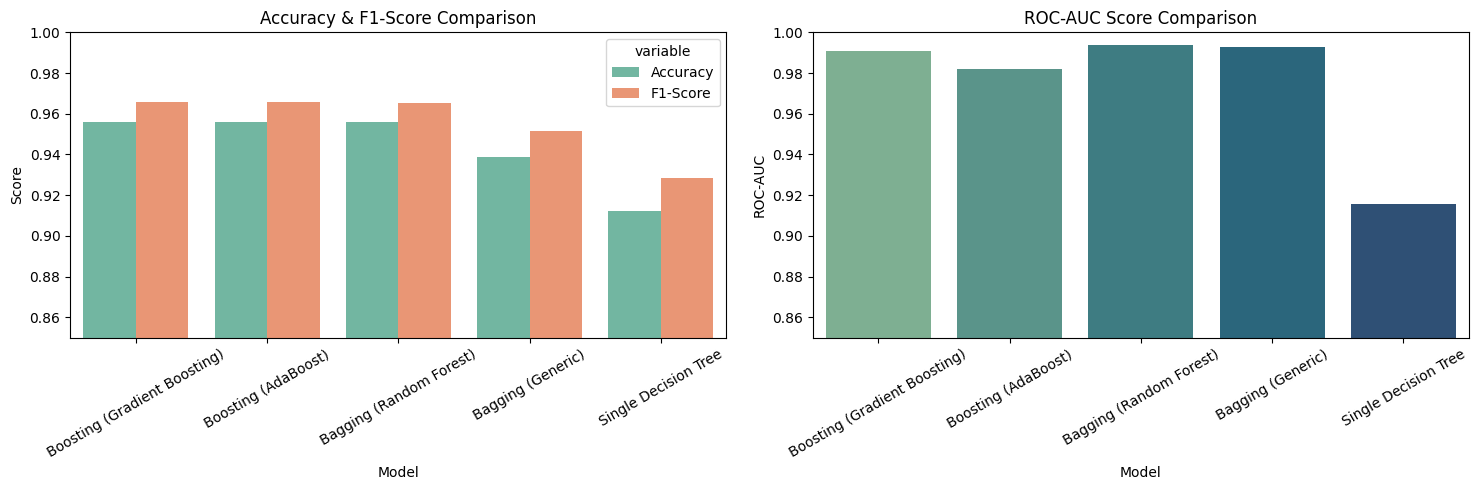

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(f"Dataset Shape: {X.shape}")
print(f"Target Distribution:\n{y.value_counts(normalize=True).map('{:.2%}'.format)}\n")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

models = {

    "Single Decision Tree": DecisionTreeClassifier(random_state=42),


    "Bagging (Generic)": BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        random_state=42
    ),
    "Bagging (Random Forest)": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),


    "Boosting (AdaBoost)": AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Boosting (Gradient Boosting)": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

metrics_data = []

for name, model in models.items():

    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    metrics_data.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })


results_df = pd.DataFrame(metrics_data).sort_values(by="F1-Score", ascending=False)

print("--- Performance Report ---")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


fig, axes = plt.subplots(1, 2, figsize=(15, 5))


results_melted = pd.melt(results_df, id_vars=["Model"], value_vars=["Accuracy", "F1-Score"])
sns.barplot(data=results_melted, x="Model", y="value", hue="variable", ax=axes[0], palette="Set2")
axes[0].set_title("Accuracy & F1-Score Comparison")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.85, 1.0)
axes[0].tick_params(axis='x', rotation=30)


sns.barplot(data=results_df, x="Model", y="ROC-AUC", ax=axes[1], palette="crest")
axes[1].set_title("ROC-AUC Score Comparison")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_ylim(0.85, 1.0)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()